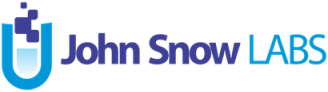

# Terminology MCP Server + Strands Agent Demo

This notebook demonstrates how to connect a **Strands AI Agent** to a **Terminology MCP Server** using OAuth 2.0 authentication over a Streamable HTTP transport.

The agent uses **Amazon Bedrock (Claude Sonnet 4)** as its underlying model and interacts with the Terminology MCP Server to perform:

- Medical terminology search (standard and context-aware)
- Concept code mapping across vocabularies
- Concept hierarchy retrieval

---

## Architecture Overview

```
Jupyter Notebook
    └── Strands Agent  (Claude Sonnet 4 via Amazon Bedrock)
            └── MCP Client  (OAuth 2.0 · Streamable HTTP)
                    └── Terminology MCP Server
```

---

## Table of Contents

1. [Install Dependencies](#1-install-dependencies)
2. [Import Libraries](#2-import-libraries)
3. [AWS Credentials Setup](#3-aws-credentials-setup)
4. [Model Initialization](#4-model-initialization)
5. [Configuration](#5-configuration)
6. [OAuth Setup](#6-oauth-setup)
7. [MCP Client Connection](#7-mcp-client-connection)
8. [Agent Initialization](#8-agent-initialization)
9. [Demo Queries](#9-demo-queries)
10. [Cleanup](#10-cleanup)

## 1. Install Dependencies

Install the required Python packages. Pin versions are used for reproducibility.

In [ ]:
!pip install strands-agents==1.24.0 strands-agents-tools==0.2.19 mcp==1.26.0 boto3==1.42.38 httpx==0.28.1


## 2. Import Libraries

In [2]:
import os
import httpx
from urllib.parse import parse_qs, urlparse

from mcp.client.streamable_http import streamable_http_client
from mcp.client.auth import OAuthClientProvider, TokenStorage
from mcp.shared.auth import OAuthClientInformationFull, OAuthToken
from strands.tools.mcp import MCPClient
from strands import Agent
from strands.models import BedrockModel

## 3. AWS Credentials Setup

> ⚠️ **Security Note:** Do not hard-code credentials in production. Use IAM roles, environment variables, or AWS Secrets Manager instead. The values below are placeholders — replace them with valid temporary credentials before running.

In [ ]:
os.environ["AWS_ACCESS_KEY_ID"] = "<YOUR_ACCESS_KEY_ID>"
os.environ["AWS_SECRET_ACCESS_KEY"] = "<YOUR_SECRET_ACCESS_KEY>"
os.environ["AWS_SESSION_TOKEN"] = "<YOUR_SESSION_TOKEN>"
os.environ["AWS_DEFAULT_REGION"] = "us-east-1"


## 4. Model Initialization

Initialize the **Amazon Bedrock** model using Claude Sonnet 4.

In [4]:
bedrock_model = BedrockModel(
    model_id="us.anthropic.claude-sonnet-4-20250514-v1:0",
    temperature=0.2,
    max_tokens=2000,
)

## 5. Configuration

Set the server URL, MCP endpoint, and OAuth client credentials.

### Server URL

Replace `<YOUR_SERVER_IP>` with the IP address of the machine where the Terminology Server is deployed.

### Client ID & Client Secret

These can only be retrieved by an **admin user** from the Terminology Server:
1. Log in to the Terminology Server as an admin.
2. Navigate to **API Service → API Service Access**.
3. Click **Get Client ID** and **Get Client Secret** to copy the values.

In [ ]:
# Server configuration — replace with your server's IP or hostname
SERVER_URL = "http://<YOUR_SERVER_IP>"
MCP_ENDPOINT = f"{SERVER_URL}/mcp"

# OAuth client configuration
# Retrieve CLIENT_ID and CLIENT_SECRET from the Terminology Server (admin only):
# API Service → API Service Access → Get Client ID / Get Client Secret
CLIENT_ID = "<YOUR_CLIENT_ID>"
CLIENT_SECRET = "<YOUR_CLIENT_SECRET>"
REDIRECT_URI = "https://127.0.0.1:3000/callback"

## 6. OAuth Setup

This section sets up the OAuth 2.0 Authorization Code flow required by the Terminology MCP Server (backed by Keycloak).

### 6.1 Token Storage

`InMemoryTokenStorage` holds OAuth tokens in memory for the duration of the session.

In [6]:
class InMemoryTokenStorage(TokenStorage):
    """In-memory token storage implementation."""
    
    def __init__(self):
        self.tokens: OAuthToken | None = None
        self.client_info: OAuthClientInformationFull | None = None
    
    async def get_tokens(self) -> OAuthToken | None:
        return self.tokens
    
    async def set_tokens(self, tokens: OAuthToken) -> None:
        self.tokens = tokens
    
    async def get_client_info(self) -> OAuthClientInformationFull | None:
        return self.client_info
    
    async def set_client_info(self, client_info: OAuthClientInformationFull) -> None:
        self.client_info = client_info

### 6.2 OAuth Callback Handlers

Two handlers are used during the authorization flow:

- **`handle_redirect`** — prints the authorization URL for the user to open in a browser.
- **`handle_callback`** — prompts the user to paste the callback URL and extracts the authorization code.

In [7]:
async def handle_redirect(auth_url: str) -> None:
    """Display the authorization URL for the user to visit."""
    print(f"\nPlease visit this URL to authorize:\n{auth_url}\n")


async def handle_callback() -> tuple[str, str | None]:
    """Get the callback URL from the user and extract the authorization code."""
    callback_url = input("Paste the callback URL here: ").strip()
    
    try:
        params = parse_qs(urlparse(callback_url).query)
        return params["code"][0], params.get("state", [None])[0]
    except (KeyError, IndexError):
        print("Error: Could not extract authorization code from URL")
        raise

### 6.3 Initialize OAuth Provider

Instantiate the `OAuthClientProvider` with the client metadata and callback handlers. This object is passed to the HTTP client as an auth handler and automatically manages the token lifecycle.

In [8]:
# Initialize token storage
storage = InMemoryTokenStorage()

# Create OAuth client metadata
client_metadata_dict = {
    "client_id": CLIENT_ID,
    "client_secret": CLIENT_SECRET,
    "client_name": "terminology_server",
    "redirect_uris": [REDIRECT_URI],
    "grant_types": ["authorization_code", "refresh_token"],
    "response_types": ["code"],
    "token_endpoint_auth_method": "client_secret_post",
}

client_info = OAuthClientInformationFull.model_validate(client_metadata_dict)
await storage.set_client_info(client_info)

# Create OAuth provider
oauth_auth = OAuthClientProvider(
    server_url=SERVER_URL,
    client_metadata=client_info,
    storage=storage,
    redirect_handler=handle_redirect,
    callback_handler=handle_callback,
)

## 7. MCP Client Connection

### 7.1 Create and Start the MCP Client

The `MCPClient` wraps the Streamable HTTP transport and the OAuth-authenticated `httpx.AsyncClient`. Calling `.start()` triggers the OAuth flow if no valid token is cached — the authorization URL will be printed and you'll be prompted to paste the callback URL.

In [10]:
def transport():
    client = httpx.AsyncClient(
        auth=oauth_auth,
        follow_redirects=True,
        
    )
    return streamable_http_client(
        url=MCP_ENDPOINT,
        http_client=client,
    )

terminology_mcp_client = MCPClient(transport, prefix="terminology")


terminology_mcp_client.start()


Please visit this URL to authorize:
http://localhost:5173/auth/realms/terminology_server/protocol/openid-connect/auth?response_type=code&client_id=terminology_server&redirect_uri=https%3A%2F%2F127.0.0.1%3A3000%2Fcallback&state=GVNxRlTGzSaOGbgtonyFb1l0UrnXZs8cszUCy2Bc0s8&code_challenge=KdznjET4MAziVHOMXa-5j0WwIcuOXKNlFlGDWBjP6Sc&code_challenge_method=S256&scope=openid+email+web-origins+basic+profile+phone+microprofile-jwt+service_account+roles+organization+offline_access+address+acr



### 7.2 List Available Tools

Retrieve and display all tools exposed by the Terminology MCP Server along with their descriptions and input parameters.

In [12]:
tools = terminology_mcp_client.list_tools_sync()

In [13]:
for t in tools:
    print("\nTool:", t.tool_name)
    print("Description:", t.tool_spec["description"])
    print("Parameters:")
    for k, v in t.tool_spec["inputSchema"]["json"]["properties"].items():
        print("  -", k, "→", v.get("description"))



Tool: terminology_search_medical_terms
Description: Searches standard codes for provided medical terms/keywords.
Allows custom valueset mapping and filtering and concept mapping for search results.


**Responses:**

- **200** (Success): Successful search response with dynamic chunks data
  - Content-Type: `application/json`

- **422**: Validation Error
  - Content-Type: `application/json`

  - **Response Properties:**

  - **Example:**
```json
{
  "detail": [
    "unknown_type"
  ]
}
```
Parameters:
  - chunks → List of keywords to search
  - vocabulary_id → Filter by vocabulary
  - standard_concept → Filter by concept standardization
  - topk → Number of top results to return
  - validity → Filter by validity status
  - domain_id → Filter by domain
  - source → Filter by source
  - concept_class_id → Filter by concept class
  - valueset_metadata_ids → Get custom code mappings of given valueset metadata id
  - source_vocabulary → Source vocabulary for Concept Maps
  - target_vocabular

## 8. Agent Initialization

Create a **Strands Agent** backed by the Bedrock model and equipped with all Terminology MCP tools discovered above.

In [16]:
agent = Agent(
    model=bedrock_model,
    tools=tools
)

## 9. Demo Queries

The following cells demonstrate the four core capabilities of the Terminology MCP Server through natural-language agent queries.

---

### 9.1 Medical Terminology Search

Search for standard medical codes using specified vocabularies.

In [17]:
response = agent(
    """
Use the MCP tools to fetch results.
Do not answer from prior knowledge.

Task:
- Search medical codes for "diabetes" and "hypertension"
- Use SNOMED and ICD10CM vocabularies
- Return top 5 results per term

You must call the appropriate MCP tool to get the data.
"""
)

print(response)


I'll search for medical codes for "diabetes" and "hypertension" using SNOMED and ICD10CM vocabularies, returning the top 5 results per term.
Tool #1: terminology_search_medical_terms
Based on the search results from the MCP tool, here are the top 5 medical codes for each term:

## Diabetes Results (Top 5):

1. **ICD10CM Z86.3** - History of diabetes mellitus type 1
   - Domain: Observation
   - Standard: Non-Standard
   - Score: 0.7058

2. **ICD10CM Z86.39** - History of diabetes mellitus type 2  
   - Domain: Observation
   - Standard: Non-Standard
   - Score: 0.7013

3. **ICD10CM E11.31** - Retinopathy co-occurrent and due to diabetes mellitus
   - Domain: Condition
   - Standard: Non-Standard
   - Score: 0.6892

4. **ICD10CM Z86.3** - History of maturity onset diabetes mellitus in young
   - Domain: Observation
   - Standard: Non-Standard
   - Score: 0.6798

5. **SNOMED 143080000** - Hb. A1c - glycated hemoglobin (& [diabetic control])
   - Domain: Measurement
   - Standard: Non-Sta

### 9.2 Context-Aware Medical Terminology Search

Performs a **context-aware** terminology search that uses a clinical narrative to improve code relevance, biasing results toward the most clinically appropriate codes.

In [18]:
response = agent(
    """
Use the MCP tools to fetch results.
Do not answer from prior knowledge.

Task:
- Search medical codes for "diabetes", "hypertension", and "pneumonia".
- Use the clinical context to improve search relevance.
- Restrict results to SNOMED and ICD10CM vocabularies.
- Return top 5 results per term.

Clinical context:
Patient is a 65-year-old male with history of hypertension and type 2 diabetes mellitus.
He presents with fever, productive cough, and shortness of breath.
Chest X-ray findings are consistent with pneumonia.

You must call the appropriate MCP tool to get the data.
"""
)

print(response)


I'll search for medical codes for "diabetes", "hypertension", and "pneumonia" using the clinical context to improve search relevance, restricting to SNOMED and ICD10CM vocabularies with top 5 results per term.
Tool #2: terminology_search_medical_terms_with_context
Based on the context-aware search results from the MCP tool, here are the top 5 medical codes for each term:

## Diabetes Results (Top 5):

1. **ICD10CM Z86.39** - History of diabetes mellitus type 2
   - Domain: Observation
   - Standard: Non-Standard
   - Score: 0.7705
   - *Note: This result scored highest due to the clinical context mentioning "type 2 diabetes mellitus"*

2. **ICD10CM Z86.3** - History of diabetes mellitus type 1
   - Domain: Observation
   - Standard: Non-Standard
   - Score: 0.7407

3. **SNOMED 143080000** - Hb. A1c - glycated hemoglobin (& [diabetic control])
   - Domain: Measurement
   - Standard: Non-Standard
   - Score: 0.7036
   - *Note: Invalid code (expired 2002-01-31)*

4. **SNOMED 165678002** -

### 9.3 Concept Code Mapping Across Vocabularies

Maps concept codes from one vocabulary to equivalent codes in another. Useful for cross-vocabulary interoperability.

In [19]:
response = agent(
    """
Use the MCP tools to fetch results.
Do not answer from prior knowledge.

Task:
- Map the medical concept codes E11 and I10 from ICD10 to another standard vocabulary.
- Return mappings available for each code.

You must call the appropriate MCP tool to retrieve the mappings.
"""
)

print(response)


I'll map the medical concept codes E11 and I10 from ICD10CM to other standard vocabularies using the MCP tool.
Tool #3: terminology_map_concept_codes
Based on the mapping results from the MCP tool, here are the available mappings for each code:

## E11 (Type 2 Diabetes Mellitus) Mappings:

**Source:** ICD10CM E11

**Target Vocabularies:**
- **UMLS:** 5 concept mappings
  - C0011847
  - C0011860
  - C0851219
  - C0854110
  - C4290093

## I10 (Essential Hypertension) Mappings:

**Source:** ICD10CM I10

**Target Vocabularies:**
- **UMLS:** 3 concept mappings
  - C0020538
  - C0085580
  - C4290132

- **SNOMED:** 30 concept mappings
  - 10725009
  - 16229371000119106
  - 170577003
  - 170587004
  - 185718005
  - 198945003
  - 24184005
  - 308502002
  - 367390009
  - 371125006
  - 38341003
  - 421731000
  - 449759005
  - 461301000124109
  - 461415008
  - 46481004
  - 59621000
  - 62275004
  - 63711009
  - 65518004
  - 697929007
  - 70272006
  - 712832005
  - 717824007
  - 72022006
  - 720568

### 9.4 Concept Hierarchy Retrieval

Retrieves the **parent concept hierarchy** for a given concept code, useful for understanding how it fits within the broader classification tree.

In [20]:
response = agent(
    """
Use the MCP tools to fetch results.
Do not answer from prior knowledge.

Task:
- Retrieve parent concepts for concept code LP191611-5 in the LOINC vocabulary.
- Return the hierarchy of parent concepts.

You must call the appropriate MCP tool to retrieve the hierarchy.
"""
)

print(response)


I'll retrieve the parent concepts for concept code LP191611-5 in the LOINC vocabulary using the MCP tool.
Tool #4: terminology_get_concept_parents
Based on the results from the MCP tool, here is the hierarchy of parent concepts for LOINC concept code LP191611-5:

## Hierarchy of Parent Concepts (Top to Bottom):

1. **root** (Top level)
   ↓
2. **LP432695-7**
   ↓
3. **LP7787-7**
   ↓
4. **LP29684-5**
   ↓
5. **LP6990-8**
   ↓
6. **LP191611-5** (Target concept)

## Hierarchy Structure:

**From Top (Root) to Bottom:**
- root → LP432695-7 → LP7787-7 → LP29684-5 → LP6990-8 → LP191611-5

**From Bottom to Top:**
- LP191611-5 → LP6990-8 → LP29684-5 → LP7787-7 → LP432695-7 → root

The concept LP191611-5 has **4 direct parent levels** above it in the LOINC hierarchy, with LP6990-8 being its immediate parent and the root being at the top of the hierarchy. This represents a 5-level deep hierarchical structure in the LOINC vocabulary system.Based on the results from the MCP tool, here is the hiera

## 10. Cleanup

Stop the MCP client to close the connection.

In [22]:
terminology_mcp_client.stop(None, None, None)